In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

plt.style.use('tableau-colorblind10')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
errbar_kwargs = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'o', 'markersize':8}
errbar_kwargs_square = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'s', 'markersize':7}
errbar_kwargs_tri = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'^', 'markersize':7}

In this notebook we generate the y-tau scaling relationships from the kSZ-derived tau values (from Gong et al. 2026 (LRG), Hadzhiyska et al. 2025 (BGS), and Hsu et al. (in prep) (eROMaPPer)) and the tSZ-derived Compton-y measurements.

# Functions

In [3]:
# converts Compton-y to tau following Eq. 14
def lntau_from_y(y, lnt0, m):
    lntau = lnt0 + m*np.log(y/1e-7)
    return lntau

# calculates statistical error on tSZ tau
def tau_err_calc(y, yerr, lnt, m):
    if y < 0:
        y = 0
    y /= 1e-7
    yerr /= 1e-7
    tau_err = np.exp(lnt+m*np.log(y+yerr)) - np.exp(lnt+m*np.log(y))
    return tau_err

# calculates systematic error from scaling relation
def mc_tau_scaling_relation_error(y, pars, n):
    if y < 0:
        y = 0
    y /= 1e-7
    ln_tau, m, err_lt, err_m = pars
    mc_ln_tau = ln_tau + np.random.normal(0, err_lt, n)
    mc_m = np.random.normal(m, err_m, n)
    mc_taus = np.exp(mc_ln_tau + mc_m*np.log(y))
    mc_taus_err = np.std(mc_taus)
    return mc_taus_err

# fits Eq. 14 to data
def fit_tau(ys, taus, tauerrs, p0, yfit=np.linspace(1e-9, 1e-5, 500)):
    popt, pcov = curve_fit(f=lntau_from_y, xdata=np.asarray(ys), ydata=np.log(np.asarray(taus)), p0=p0, sigma=np.log(np.asarray(tauerrs)))
    lntaufit = lntau_from_y(yfit, *popt)
    fiterr = np.sqrt(pcov[1,1] + np.log(yfit)**2 * pcov[0,0] + 2*np.log(yfit)*pcov[0,1])
    stds = np.sqrt(np.diag(pcov))
    return popt, stds, lntaufit, fiterr

# tSZ Compton-y measurements

Note here we do not use the beam-corrected values that are plotted in Figure 12. The main purpose of the beam correction in the tSZ measurements is to allow an accurate comparison of measured Compton y within the different ACT maps. In these plots we are developing relationships from the tSZ+kSZ measurements using the same maps. The kSZ analyses do not employ beam corrections, thus we do not use the beam corrected values here.

In [4]:
lrg_bins =['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']
bgs_bins = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
opt_bins = ['L5', 'L10', 'L20', 'L5D', 'L10D']
yaps = pd.DataFrame()
aps = [2.1, 2.7, 2.4]
for f in ['f090', 'f150']:
    for lum in lrg_bins:
        profiles = pd.read_csv(f'profiles/{f}_lrg_{lum}_profile_deproj.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_deproj'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_deproj_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_lrg_{lum}_radio_clean_profile_deproj.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_err'].values[0]
    for lum in bgs_bins:
        profiles = pd.read_csv(f'profiles/{f}_bgs_{lum}_profile_deproj.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_deproj'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_deproj_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_bgs_{lum}_radio_clean_profile_deproj.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_err'].values[0]
    for lum in opt_bins:
        profiles = pd.read_csv(f'profiles/{f}_opt_{lum}_profile_deproj.csv')
        profiles_rc = pd.read_csv(f'profiles/{f}_opt_{lum}_radio_clean_profile_deproj.csv')
        if lum in ['L5', 'L10', 'L5D', 'L10D']:
            if lum == 'L5D': # both full/clean deprojected
                yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_deproj'].values[0]
                yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_deproj_err'].values[0]
            else: # clean deprojected
                yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy'].values[0]
                yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_deproj'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_deproj_err'].values[0]
        else: # none deprojected
            yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy'].values[0]
            yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_err'].values[0]
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    for lum in lrg_bins:
        profiles = pd.read_csv(f'profiles/{f}_lrg_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_lrg_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_err'].values[0]
    for lum in bgs_bins:
        profiles = pd.read_csv(f'profiles/{f}_bgs_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_bgs_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_err'].values[0]
    for lum in opt_bins:
        profiles = pd.read_csv(f'profiles/{f}_opt_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_opt_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_err'].values[0]
yaps

,f090_dy,f090_dy_err,f150_dy,f150_dy_err,ilc_dy,ilc_dy_err,ilc_cib_1.6_10.7_dy,ilc_cib_1.6_10.7_dy_err,ilc_db_1.6_10.7_dy,ilc_db_1.6_10.7_dy_err
L36,1.946978e-08,2.160171e-09,2.135062e-08,3.305204e-09,3.092797e-08,1.765241e-09,3.736527e-08,2.046513e-09,2.125392e-08,6.823888e-09
L36_rc,7.935665e-08,2.066725e-09,7.270674e-08,3.727529e-09,5.936624e-08,1.968510e-09,6.493519e-08,2.280380e-09,6.678540e-08,7.335453e-09
L48,2.318095e-08,2.499169e-09,2.545274e-08,3.789619e-09,3.769444e-08,2.031499e-09,4.459858e-08,2.372022e-09,2.967242e-08,7.692146e-09
L48_rc,8.564957e-08,2.356959e-09,7.930849e-08,4.245246e-09,6.744451e-08,2.296736e-09,7.405129e-08,2.698090e-09,7.997315e-08,8.322036e-09
L60,3.163377e-08,3.119720e-09,3.349067e-08,4.665146e-09,5.100266e-08,2.509728e-09,5.768892e-08,2.895470e-09,3.631534e-08,9.401594e-09
L60_rc,9.509027e-08,2.759689e-09,9.003479e-08,5.120596e-09,8.110931e-08,2.849939e-09,8.727844e-08,3.269952e-09,8.881836e-08,1.033764e-08
L79,4.348433e-08,4.522284e-09,5.398305e-08,6.519030e-09,7.623857e-08,3.649631e-09,8.473451e-08,4.145041e-09,4.635114e-08,1.304163e-08
L79_rc,1.090744e-07,3.752008e-09,1.084146e-07,7.049701e-09,1.065397e-07,4.058306e-09,1.141520e-07,4.671697e-09,1.009610e-07,1.494758e-08
L98,7.239846e-08,6.606018e-09,7.876414e-08,9.591814e-09,1.175013e-07,5.192440e-09,1.293713e-07,5.947451e-09,8.750180e-08,1.838107e-08
L98_rc,1.377876e-07,5.259111e-09,1.254033e-07,1.010647e-08,1.459605e-07,5.889902e-09,1.591832e-07,6.602528e-09,1.515833e-07,2.078903e-08


# LRG scaling relation

In [174]:
# for the LRG sample, Yulin used a simulated map + sample to determine lnt0 and m
# he found lnt0 = -9.42 +/- 0.01 and m = 0.45 +/- 0.02
# here we use those values to construct a model 
yulin_lnt0 = -9.42
yulin_lnt0_err = 0.01
yulin_m = 0.45
yulin_m_err = 0.02

# generate model y-tau
y_model = np.linspace(1e-9, 1.5e-7, 500)
tau_model = np.exp(lntau_from_y(y_model, yulin_lnt0, yulin_m))

# compute error
pars = [yulin_lnt0, yulin_m, yulin_lnt0_err, yulin_m_err]
tau_err_model = np.asarray([mc_tau_scaling_relation_error(y, pars=pars, n=10000) for y in y_model])

In [175]:
# now we read in the kSZ-derived tau measurements
ksz_tau_lrg_f150 = pd.read_csv('ksz_tau/lrg_f150_tau.csv', index_col=0) # values from Table II of Gong+2026
ksz_tau_lrg_f150

,tau,tau_err
L36,0.000042,0.000006
L48,0.000043,0.000006
L60,0.000044,0.000008
L79,0.000049,0.000011
L98,0.000055,0.000018
L36D,0.000036,0.000012
L48D,0.000043,0.000011
L60D,0.000025,0.000011
L79D,0.000034,0.000018


In [176]:
ksz_tau_lrg_ilc = pd.read_csv('ksz_tau/lrg_ilc_tau.csv', index_col=0)
ksz_tau_lrg_ilc

,tau,tau_err
L36,0.000046,0.000005
L48,0.000051,0.000006
L60,0.000054,0.000007
L79,0.000058,0.000010
L98,0.000062,0.000016
L36D,0.000027,0.000011
L48D,0.000041,0.000010
L60D,0.000044,0.000010
L79D,0.000046,0.000017


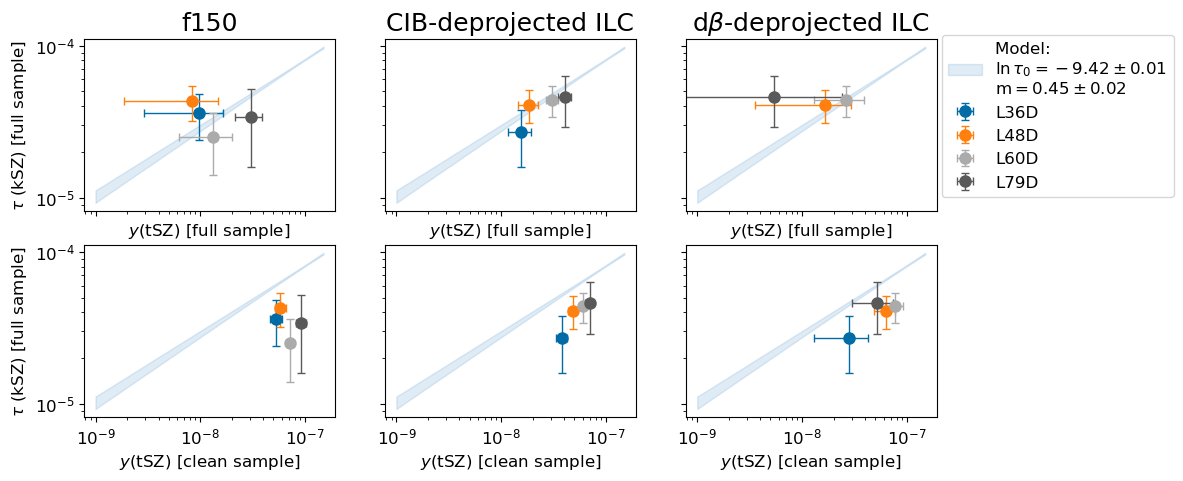

In [177]:
# plot y-tau (Figure 13)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axs = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
lums = ['L36D', 'L48D', 'L60D', 'L79D']
labels = ['f150', 'CIB-deprojected ILC', r'd$\beta$-deprojected ILC']
inds = ['', '_rc']
figure_data = pd.DataFrame()
for i, m in enumerate(['f150', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']):
    axs[0, i].set_title(labels[i])
    for lum in lums:
        if 'f' in m:
            ydata = ksz_tau_lrg_f150.loc[lum, 'tau']
            yerr = ksz_tau_lrg_f150.loc[lum, 'tau_err']
        else:
            ydata = ksz_tau_lrg_ilc.loc[lum, 'tau']
            yerr = ksz_tau_lrg_ilc.loc[lum, 'tau_err']
        for j, ind in enumerate(inds):
            xdata = yaps.loc[lum+ind, m+'_dy']
            xerr = yaps.loc[lum+ind, m+'_dy_err']
            
            figure_data.loc[lum+ind, m+'_y'] = xdata
            figure_data.loc[lum+ind, m+'_y_err'] = xerr
            figure_data.loc[lum+ind, m+'_tau'] = ydata
            figure_data.loc[lum+ind, m+'_tau_err'] = yerr
            
            # skip negative values
            mask = np.array(xdata) >= 0
            xdata_plot = np.array(xdata)[mask]
            ydata_plot = np.array(ydata)[mask]
            xerr_plot = np.array(xerr)[mask] if xerr is not None else None
            yerr_plot = np.array(yerr)[mask] if yerr is not None else None
            axs[j, i].errorbar(xdata_plot, ydata_plot, xerr=xerr_plot, yerr=yerr_plot, label=lum, **errbar_kwargs)

for ax in axs.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)        
    ax.fill_between(
        y_model, 
        y1=(tau_model - tau_err_model), 
        y2=(tau_model + tau_err_model), 
        color=colors[4], alpha=0.2,
        label='Model: \n'+r'$\ln\tau_0=-9.42 \pm 0.01$'+'\n'+r'm$=0.45\pm0.02$'
    )

for ax in axs[0, :]:
        ax.set_xlabel(r'$y (\mathrm{tSZ})$ [full sample]')
for ax in axs[1, :]:
        ax.set_xlabel(r'$y (\mathrm{tSZ})$ [clean sample]')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]')
handles, labels_legend = axs[0,0].get_legend_handles_labels()
fig.legend(
    handles, labels_legend,
    loc='upper center', ncol=1,#len(at_bgs.bin_labels),
    fontsize=12, bbox_to_anchor=(1.01, 0.9), frameon=True
)
plt.subplots_adjust(bottom=0.25)

In [119]:
figure_data.to_csv('figure_data/figure13.csv')

In [120]:
np.savez('figure_data/figure13_model.npz', y_model=y_model, tau_model=tau_model, tau_err_model=tau_err_model)

In [184]:
# convert tSZ y to tau and save for Figure 17 plot
tau_df = pd.DataFrame()
for m in ['f150', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    for lum in lums:
        for ind in inds:
            tau_df.loc[lum+ind, m+'_tsz_tau'] = np.exp(lntau_from_y(yaps.loc[lum+ind, m+'_dy'], yulin_lnt0, yulin_m))
            tau_df.loc[lum+ind, m+'_tsz_tau_staterr'] = tau_err_calc(yaps.loc[lum+ind, m+'_dy'], yaps.loc[lum+ind, m+'_dy_err'], yulin_lnt0, yulin_m)
            tau_df.loc[lum+ind, m+'_tsz_tau_syserr'] = mc_tau_scaling_relation_error(yaps.loc[lum+ind, m+'_dy'],[yulin_lnt0, yulin_m, yulin_lnt0_err, yulin_m_err], 10000)
for lum in lums:
    for ind in inds:
        tau_df.loc[lum+ind, 'f150_ksz_tau'] = ksz_tau_lrg_f150.loc[lum, 'tau']
        tau_df.loc[lum+ind, 'f150_ksz_tau_err'] = ksz_tau_lrg_f150.loc[lum, 'tau_err']
        tau_df.loc[lum+ind, 'ilc_ksz_tau'] = ksz_tau_lrg_ilc.loc[lum, 'tau']
        tau_df.loc[lum+ind, 'ilc_ksz_tau_err'] = ksz_tau_lrg_ilc.loc[lum, 'tau_err']

tau_df.to_csv('figure_data/figure17_lrg.csv')
tau_df

/tmp/ipykernel_3921165/2711279998.py:3: RuntimeWarning: invalid value encountered in log
  lntau = lnt0 + m*np.log(y/1e-7)
/tmp/ipykernel_3921165/2711279998.py:12: RuntimeWarning: divide by zero encountered in log
  tau_err = np.exp(lnt+m*np.log(y+yerr)) - np.exp(lnt+m*np.log(y))
/tmp/ipykernel_3921165/2711279998.py:23: RuntimeWarning: divide by zero encountered in log
  mc_taus = np.exp(mc_ln_tau + mc_m*np.log(y))


,f150_tsz_tau,f150_tsz_tau_staterr,f150_tsz_tau_syserr,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,f150_ksz_tau,f150_ksz_tau_err,ilc_ksz_tau,ilc_ksz_tau_err
L36D,0.000028,0.000008,1.370171e-06,0.000035,0.000004,1.344810e-06,NaN,0.000033,0.000000e+00,0.000036,0.000012,0.000027,0.000011
L36D_rc,0.000061,0.000003,9.868713e-07,0.000052,0.000003,1.143949e-06,0.000046,0.000010,1.244133e-06,0.000036,0.000012,0.000027,0.000011
L48D,0.000026,0.000008,1.352133e-06,0.000038,0.000003,1.345344e-06,0.000036,0.000011,1.349435e-06,0.000043,0.000011,0.000041,0.000010
L48D_rc,0.000064,0.000003,9.353784e-07,0.000058,0.000002,1.029250e-06,0.000066,0.000006,8.910604e-07,0.000043,0.000011,0.000041,0.000010
L60D,0.000033,0.000007,1.372166e-06,0.000048,0.000003,1.237873e-06,0.000044,0.000009,1.261297e-06,0.000025,0.000011,0.000044,0.000010
L60D_rc,0.000070,0.000003,8.320764e-07,0.000065,0.000002,9.160177e-07,0.000072,0.000006,8.145676e-07,0.000025,0.000011,0.000044,0.000010
L79D,0.000047,0.000006,1.214632e-06,0.000054,0.000003,1.111545e-06,0.000022,0.000021,1.292251e-06,0.000034,0.000018,0.000046,0.000017
L79D_rc,0.000078,0.000004,7.885733e-07,0.000069,0.000003,8.501460e-07,0.000060,0.000010,1.001012e-06,0.000034,0.000018,0.000046,0.000017


Text(0, 0.5, '$\\tau$')

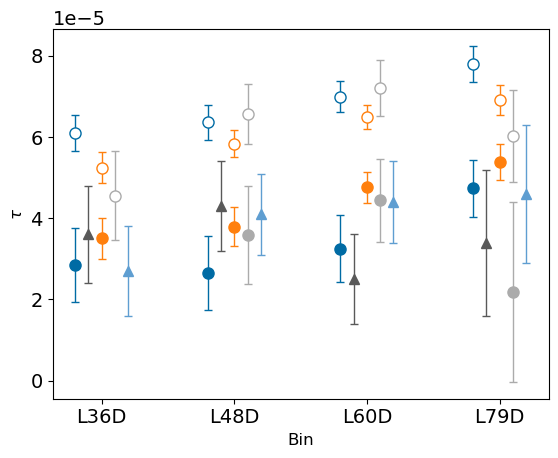

In [189]:
mfcs = [None, 'white']
names = ['f150 tSZ ', 'CIB-deproj. tSZ ', r'd$\beta$-deproj. tSZ ', 'f150 kSZ ', 'ILC kSZ ']
skips = [0, 0.2, 0.3]
for j, m in enumerate(['f150', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']):
    for i, lum in enumerate(lums):
        for k, ind in enumerate(inds):
            combined_err = tau_df.loc[lum+ind, m+'_tsz_tau_staterr']+tau_df.loc[lum+ind, m+'_tsz_tau_syserr']
            plt.errorbar(i+skips[j], tau_df.loc[lum+ind, m+'_tsz_tau'], yerr=combined_err, color=colors[j], mfc=mfcs[k], label=names[j]+ind, **errbar_kwargs)
for i, lum in enumerate(lums):
    plt.errorbar(i+0.1, tau_df.loc[lum+ind, 'f150_ksz_tau'], yerr=tau_df.loc[lum+ind, 'f150_ksz_tau_err'], color=colors[3], label=names[3], **errbar_kwargs_tri)
    plt.errorbar(i+0.4, tau_df.loc[lum+ind, 'ilc_ksz_tau'], tau_df.loc[lum+ind, 'ilc_ksz_tau_err'], color=colors[4], label=names[4], **errbar_kwargs_tri)
plt.xticks(np.arange(len(lums))+0.2, lums)
plt.xlabel('Bin')
plt.ylabel(r'$\tau$')

# BGS scaling relation

In [190]:
# SIMBA y-tau data from Boryana (discussed in Hadzhiyska et al. 2025 Appendix B)
sim_ytau_bgs = pd.read_csv('ksz_tau/bgs_SIMBA_ytau.csv', index_col=0)
# kSZ-derived taus from Hadzhiyska et al. 2025 Table II
ksz_bgs_tau = pd.read_csv('ksz_tau/bgs_ilc_tau.csv', index_col=0)

In [191]:
sim_ytau_bgs

,y,y_err,tau,tau_err
0,8.624459e-09,6.431710e-09,0.000008,0.000002
1,9.654069e-09,6.764541e-09,0.000009,0.000002
2,1.539367e-08,8.787973e-09,0.000010,0.000002
3,2.523301e-08,1.189869e-08,0.000013,0.000003
4,2.580007e-08,8.385867e-09,0.000019,0.000003
5,4.243716e-08,1.124930e-08,0.000030,0.000004
6,7.527861e-08,1.799014e-08,0.000041,0.000006
7,1.414726e-07,2.727923e-08,0.000075,0.000019
8,2.638831e-07,4.133136e-08,0.000173,0.000044
9,3.844298e-07,5.989895e-08,0.000241,0.000063


In [192]:
ksz_bgs_tau

,tau,tau_err
M10,0.000012,0.000006
M10.25,0.000022,0.000007
M10.5,0.000022,0.000008
M10.75,0.000033,0.000009
M11,0.000054,0.000011
M11.25,0.000052,0.000019


In [193]:
# Fit scaling relation to SIMBA data
# use the LRG parameters for initial guesses

tau0_guess = -9.42
m_guess = 0.45
p0 = [tau0_guess, m_guess]
y_model = np.linspace(1e-9, 6e-7, 500)

popt, stds, lntaufit, fiterr = fit_tau(sim_ytau_bgs['y'].values, sim_ytau_bgs['tau'].values, sim_ytau_bgs['tau_err'].values, p0, y_model)
taufit = np.exp(lntaufit)

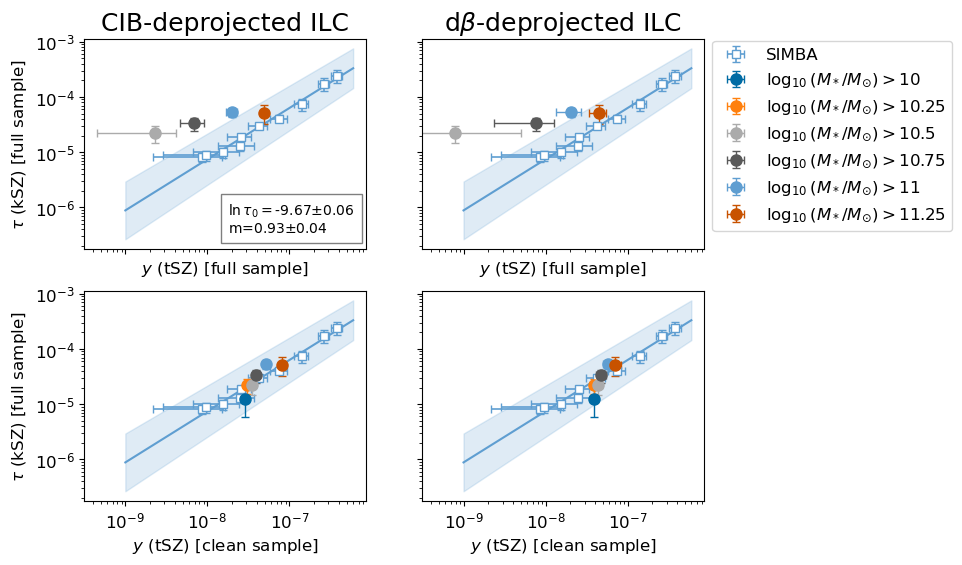

In [194]:
# --- Fonts / style ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)

labels = ['CIB-deprojected ILC', r'd$\beta$-deprojected ILC']
ms = ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
inds = ['', '_rc']
lums = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']

# plot the model
for ax in axs.flatten():
    ax.errorbar(sim_ytau_bgs['y'].values, sim_ytau_bgs['tau'].values, xerr=sim_ytau_bgs['y_err'], yerr=sim_ytau_bgs['tau_err'], color=colors[4], marker='s', lw=0, elinewidth=1.2, capsize=3, mfc='white', label='SIMBA')#: \n12.5 < M < 13.8')
    t_low  = np.exp(lntaufit - fiterr)
    t_high = np.exp(lntaufit + fiterr)
    ax.plot(y_model, taufit, color=colors[4])
    ax.fill_between(y_model, t_low, t_high, alpha=0.2, color=colors[4])

figure_data = pd.DataFrame()
# plot the data points
for i, m in enumerate(ms):
    axs[0, i].set_title(labels[i])
    for lum in lums:
        ydata = ksz_bgs_tau.loc[lum, 'tau']
        yerr = ksz_bgs_tau.loc[lum, 'tau_err']
        for j, ind in enumerate(inds):
            xdata = yaps.loc[lum+ind, m+'_dy']
            xerr = yaps.loc[lum+ind, m+'_dy_err']
            figure_data.loc[lum+ind, m+'_y'] = xdata
            figure_data.loc[lum+ind, m+'_y_err'] = xerr
            figure_data.loc[lum+ind, m+'_tau'] = ydata
            figure_data.loc[lum+ind, m+'_tau_err'] = yerr
            
            # skip negative values
            mask = np.array(xdata) >= 0
            xdata_plot = np.array(xdata)[mask]
            ydata_plot = np.array(ydata)[mask]
            xerr_plot = np.array(xerr)[mask] if xerr is not None else None
            yerr_plot = np.array(yerr)[mask] if yerr is not None else None
            axs[j, i].errorbar(xdata_plot, ydata_plot, xerr=xerr_plot, yerr=yerr_plot, label=r'$\log_{10}(M_*/M_{\odot}) >$' +f'{lum[1:]}', **errbar_kwargs)

for ax in axs.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)

axs[0,0].text(1.8e-8, 3.5e-7, r'$\ln\tau_0=$'+f'{popt[0]:.2f}'+r'$\pm$'+f'{stds[0]:.2f}'+'\n'+f'm={popt[1]:.2f}'+r'$\pm$'+f'{stds[1]:.2f}', fontsize=10,bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})

for ax in axs[:, 0]:
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]')

handles, labels_legend = axs[1, 1].get_legend_handles_labels()

for ax in axs[0, :]:
    ax.set_xlabel(r'$y\ (\mathrm{tSZ})$ [full sample]')

for ax in axs[1, :]:
    ax.set_xlabel(r'$y\ (\mathrm{tSZ})$ [clean sample]')

fig.legend(handles, labels_legend,loc='upper center', fontsize=12, bbox_to_anchor=(1.06, 0.89), frameon=True)

In [126]:
figure_data.to_csv('figure_data/figure14.csv')

In [127]:
np.savez('figure_data/figure14_model.npz', simba_y=sim_ytau_bgs['y'].values, simba_y_err=sim_ytau_bgs['y_err'].values, simba_tau=sim_ytau_bgs['tau'].values, simba_tau_err=sim_ytau_bgs['tau_err'].values, y_model=y_model, taufit=taufit, t_low=t_low, t_high=t_high, popt=popt, stds=stds)

In [195]:
# convert tSZ y to tau and save for Figure 17 plot
tau_df = pd.DataFrame()
for m in ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    for lum in lums:
        for ind in inds:
            tau_df.loc[lum+ind, m+'_tsz_tau'] = np.exp(lntau_from_y(yaps.loc[lum+ind, m+'_dy'], popt[0], popt[1]))
            tau_df.loc[lum+ind, m+'_tsz_tau_staterr'] = tau_err_calc(yaps.loc[lum+ind, m+'_dy'], yaps.loc[lum+ind, m+'_dy_err'], popt[0], popt[1])
            tau_df.loc[lum+ind, m+'_tsz_tau_syserr'] = mc_tau_scaling_relation_error(yaps.loc[lum+ind, m+'_dy'],[popt[0], popt[1], stds[0], stds[1]], 10000)
for lum in lums:
    for ind in inds:
        tau_df.loc[lum+ind, 'ilc_ksz_tau'] = ksz_bgs_tau.loc[lum, 'tau']
        tau_df.loc[lum+ind, 'ilc_ksz_tau_err'] = ksz_bgs_tau.loc[lum, 'tau_err']

tau_df.to_csv('figure_data/figure17_bgs.csv')
tau_df

/tmp/ipykernel_3921165/2711279998.py:3: RuntimeWarning: invalid value encountered in log
  lntau = lnt0 + m*np.log(y/1e-7)
/tmp/ipykernel_3921165/2711279998.py:12: RuntimeWarning: divide by zero encountered in log
  tau_err = np.exp(lnt+m*np.log(y+yerr)) - np.exp(lnt+m*np.log(y))
/tmp/ipykernel_3921165/2711279998.py:23: RuntimeWarning: divide by zero encountered in log
  mc_taus = np.exp(mc_ln_tau + mc_m*np.log(y))
/tmp/ipykernel_3921165/2711279998.py:3: RuntimeWarning: invalid value encountered in log
  lntau = lnt0 + m*np.log(y/1e-7)
/tmp/ipykernel_3921165/2711279998.py:12: RuntimeWarning: divide by zero encountered in log
  tau_err = np.exp(lnt+m*np.log(y+yerr)) - np.exp(lnt+m*np.log(y))
/tmp/ipykernel_3921165/2711279998.py:23: RuntimeWarning: divide by zero encountered in log
  mc_taus = np.exp(mc_ln_tau + mc_m*np.log(y))
/tmp/ipykernel_3921165/2711279998.py:3: RuntimeWarning: invalid value encountered in log
  lntau = lnt0 + m*np.log(y/1e-7)
/tmp/ipykernel_3921165/2711279998.py:12

,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,ilc_ksz_tau,ilc_ksz_tau_err
M10,NaN,0.000001,0.000000e+00,NaN,0.000003,0.000000e+00,0.000012,0.000006
M10_rc,0.000020,0.000001,1.564710e-06,2.616707e-05,0.000003,1.863909e-06,0.000012,0.000006
M10.25,NaN,0.000001,0.000000e+00,NaN,0.000003,0.000000e+00,0.000022,0.000007
M10.25_rc,0.000021,0.000001,1.614614e-06,2.656078e-05,0.000003,1.881841e-06,0.000022,0.000007
M10.5,0.000002,0.000001,3.269978e-07,7.027055e-07,0.000003,1.539344e-07,0.000022,0.000008
M10.5_rc,0.000024,0.000001,1.740775e-06,2.918101e-05,0.000003,1.990813e-06,0.000022,0.000008
M10.75,0.000005,0.000002,6.765487e-07,5.767910e-06,0.000004,7.160457e-07,0.000033,0.000009
M10.75_rc,0.000027,0.000002,1.876369e-06,3.187267e-05,0.000004,2.123470e-06,0.000033,0.000009
M11,0.000014,0.000002,1.253589e-06,1.433369e-05,0.000004,1.308314e-06,0.000054,0.000011
M11_rc,0.000034,0.000002,2.252150e-06,3.803400e-05,0.000005,2.412726e-06,0.000054,0.000011


Text(0, 0.5, '$\\tau$')

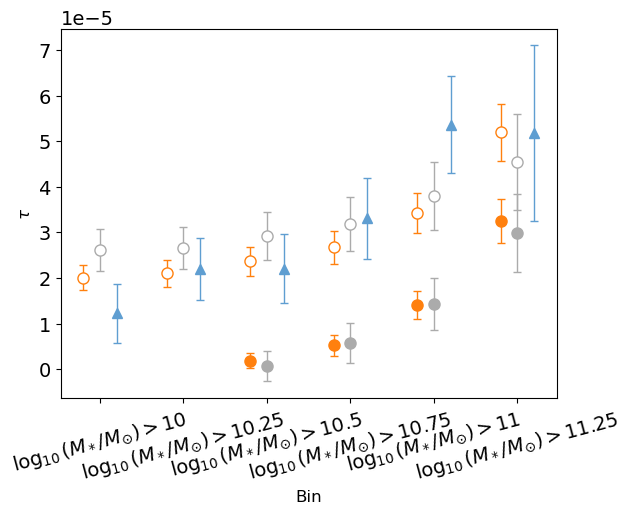

In [206]:
mfcs = [None, 'white']
names = ['CIB-deproj. tSZ ', r'd$\beta$-deproj. tSZ ', 'ILC kSZ ']
skips = [0, 0.2, 0.3]
for j, m in enumerate(['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']):
    for i, lum in enumerate(lums):
        for k, ind in enumerate(inds):
            combined_err = tau_df.loc[lum+ind, m+'_tsz_tau_staterr']+tau_df.loc[lum+ind, m+'_tsz_tau_syserr']
            plt.errorbar(i+skips[j], tau_df.loc[lum+ind, m+'_tsz_tau'], yerr=combined_err, color=colors[1+j], mfc=mfcs[k], label=names[j]+ind, **errbar_kwargs)
for i, lum in enumerate(lums):
    plt.errorbar(i+0.4, tau_df.loc[lum+ind, 'ilc_ksz_tau'], tau_df.loc[lum+ind, 'ilc_ksz_tau_err'], color=colors[4], label=names[2], **errbar_kwargs_tri)
plt.xticks(np.arange(len(lums))+0.2, [r'$\log_{10}(M_*/M_{\odot}) >$' +f'{lum[1:]}' for lum in lums], rotation=15)
plt.xlabel('Bin')
plt.ylabel(r'$\tau$')

# eROMaPPer (optical) scaling relation

In [5]:
# kSZ-derived tau values from Yun-Hsin Hsu (paper in prep)
ksz_opt_tau = pd.read_csv('ksz_tau/opt_ilc_tau.csv', index_col=0)

In [6]:
ksz_opt_tau

,tau,tau_err
L5,0.000063,0.000010
L10,0.000125,0.000022
L20,0.000213,0.000065
L5D,0.000034,0.000012
L10D,0.000081,0.000021


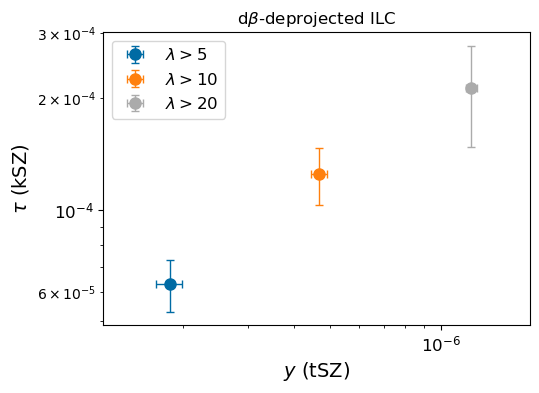

In [9]:
# plot y and tau for the original (non-disjoint) bins
plt.figure(figsize=[5.5,3.8])

label = r'd$\beta$-deprojected ILC'
m = 'ilc_db_1.6_10.7'
plotlabels = [r'$\lambda >5$', r'$\lambda > 10$', r'$\lambda > 20$']

labs = ['L5', 'L10', 'L20']
plt.title(label)
figure_data = pd.DataFrame()
for j, lum in enumerate(labs):
    xdata = yaps.loc[lum, m+'_dy']
    xerr = yaps.loc[lum, m+'_dy_err']
    ydata = ksz_opt_tau.loc[lum, 'tau']
    yerr = ksz_opt_tau.loc[lum, 'tau_err']
    figure_data.loc[lum, m+'_y'] = xdata
    figure_data.loc[lum, m+'_y_err'] = xerr
    figure_data.loc[lum, m+'_tau'] = ydata
    figure_data.loc[lum, m+'_tau_err'] = yerr
    
    plt.errorbar(xdata, ydata, xerr=xerr, yerr=yerr,label=plotlabels[j], **errbar_kwargs)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$y\ (\mathrm{tSZ})$', fontsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=12)
plt.gca().set_aspect(aspect='equal', adjustable='datalim')  # make square
plt.ylabel(r'$\tau \ (\mathrm{kSZ})$', fontsize=14)
plt.legend(loc='upper left', fontsize=12, frameon=True)

In [10]:
figure_data.to_csv('figure_data/figure15.csv')

In [11]:
# fit scaling relation to data
# use the LRG parameters as initial guesses
m = 'ilc_db_1.6_10.7'
inds = ['', '_rc']
samps = ['full_sample', 'radio_clean']
lums = ['L5D', 'L10D', 'L20']
tau0_guess = -9.42
m_guess = 0.45
p0 = [tau0_guess, m_guess]
y_model = np.linspace(1e-9, 1e-5, 500)
popt = {}
stds = {}
lntaufit = {}
taufit = {}
fiterr = {}
taus = ksz_opt_tau.loc[['L5D', 'L10D', 'L20']]['tau'].values
tauerrs = ksz_opt_tau.loc[['L5D', 'L10D', 'L20']]['tau_err'].values
for i, ind in enumerate(inds):
    samp = samps[i]
    ys = [yaps.loc[lum+ind, m+'_dy'] for lum in lums]
    yerrs = [yaps.loc[lum+ind, m+'_dy_err'] for lum in lums]
    popt[samp], stds[samp], lntaufit[samp], fiterr[samp] = fit_tau(ys, taus, tauerrs, p0, y_model)
    taufit[samp] = np.exp(lntaufit[samp])

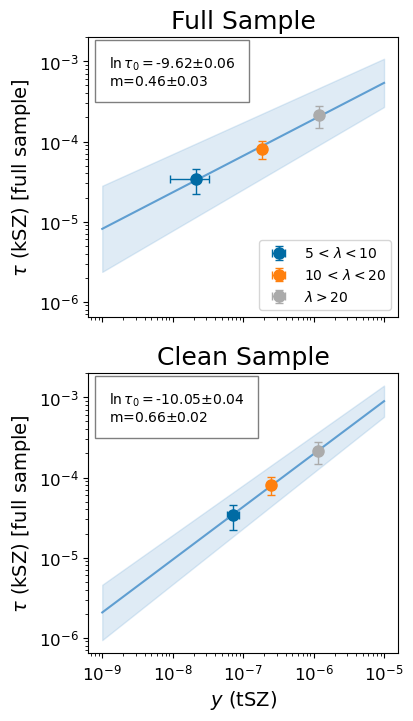

In [12]:
# --- Fonts / style ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
m = 'ilc_db_1.6_10.7'
inds = ['', '_rc']
samps = ['full_sample', 'radio_clean']
labels = ['Full Sample', 'Clean Sample']
plotlabels = [r'5 < $\lambda < 10$', r'10 < $\lambda < 20$', r'$\lambda > 20$']
lums = ['L5D', 'L10D', 'L20']
taus = ksz_opt_tau.loc[['L5D', 'L10D', 'L20']]['tau'].values
tauerrs = ksz_opt_tau.loc[['L5D', 'L10D', 'L20']]['tau_err'].values
y_model=np.linspace(1e-9, 1e-5, 500)

fig, axs = plt.subplots(2, 1, figsize=(4, 8), sharex=True, sharey=True)
figure_data = pd.DataFrame()
t_lows = {}
t_highs = {}
for i, ind in enumerate(inds):
    axs[i].set_title(labels[i])
    samp = samps[i]
    ys = [yaps.loc[lum+ind, m+'_dy'] for lum in lums]
    yerrs = [yaps.loc[lum+ind, m+'_dy_err'] for lum in lums]
    for j, lum in enumerate(lums):
        axs[i].errorbar(ys[j], taus[j],xerr=yerrs[j], yerr=tauerrs[j],label=plotlabels[j], **errbar_kwargs)
        figure_data.loc[lum+ind, m+'_y'] = ys[j]
        figure_data.loc[lum+ind, m+'_y_err'] = yerrs[j]
        figure_data.loc[lum+ind, m+'_tau'] = taus[j]
        figure_data.loc[lum+ind, m+'_tau_err'] = tauerrs[j]
    axs[i].plot(y_model, taufit[samp], color=colors[4])
    t_low  = np.exp(lntaufit[samp] - fiterr[samp])
    t_lows[samp] = t_low
    t_high = np.exp(lntaufit[samp] + fiterr[samp])
    t_highs[samp] = t_high
    axs[i].fill_between(y_model, t_low, t_high, alpha=0.2, color=colors[4])
    axs[i].text(1.25e-9, 5e-4, r'$\ln\tau_0=$'+f'{popt[samp][0]:.2f}'+r'$\pm$'+f'{stds[samp][0]:.2f}'+'\n'+f'm={popt[samp][1]:.2f}'+r'$\pm$'+f'{stds[samp][1]:.2f}', fontsize=10,bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 10})

for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]', fontsize=14)

axs[1].set_xlabel(r'$y\ (\mathrm{tSZ})$', fontsize=14)

axs[0].legend(loc='lower right',fontsize=10, frameon=True)
# plt.savefig('/hpc/group/cosmology/jem189/scratch/plots/paper_plots_20260520/opt_ytau_withfit.pdf', bbox_inches='tight', pad_inches=0.1)

In [13]:
figure_data.to_csv('figure_data/figure16.csv')

In [14]:
for samp in samps:
    np.savez(f'figure_data/figure16_model_{samp}.npz', y_model=y_model, popt=popt[samp], stds=stds[samp], taufit=taufit[samp], t_low=t_lows[samp], t_high=t_highs[samp])

In [15]:
# convert tSZ y to tau and save for Figure 17 plot
tau_df = pd.DataFrame()
for m in ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    for lum in lums:
        for i, ind in enumerate(inds):
            tau_df.loc[lum+ind, m+'_tsz_tau'] = np.exp(lntau_from_y(yaps.loc[lum+ind, m+'_dy'], popt[samps[i]][0], popt[samps[i]][1]))
            tau_df.loc[lum+ind, m+'_tsz_tau_staterr'] = tau_err_calc(yaps.loc[lum+ind, m+'_dy'], yaps.loc[lum+ind, m+'_dy_err'], popt[samps[i]][0], popt[samps[i]][1])
            tau_df.loc[lum+ind, m+'_tsz_tau_syserr'] = mc_tau_scaling_relation_error(yaps.loc[lum+ind, m+'_dy'],[popt[samps[i]][0], popt[samps[i]][1], stds[samps[i]][0], stds[samps[i]][1]], 10000)
for lum in lums:
    for ind in inds:
        tau_df.loc[lum+ind, 'ilc_ksz_tau'] = ksz_opt_tau.loc[lum, 'tau']
        tau_df.loc[lum+ind, 'ilc_ksz_tau_err'] = ksz_opt_tau.loc[lum, 'tau_err']

tau_df.to_csv('figure_data/figure17_opt.csv')
tau_df

,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,ilc_ksz_tau,ilc_ksz_tau_err
L5D,0.000032,0.000004,0.000003,0.000033,0.000007,0.000003,0.000034,0.000012
L5D_rc,0.000033,0.000002,0.000001,0.000035,0.000004,0.000001,0.000034,0.000012
L10D,0.000086,0.000002,0.000005,0.000088,0.000004,0.000006,0.000081,0.000021
L10D_rc,0.000077,0.000002,0.000003,0.000078,0.000005,0.000003,0.000081,0.000021
L20,0.000206,0.000002,0.000021,0.000206,0.000003,0.000021,0.000213,0.000065
L20_rc,0.000212,0.000004,0.000014,0.000216,0.000006,0.000015,0.000213,0.000065


Text(0, 0.5, '$\\tau$')

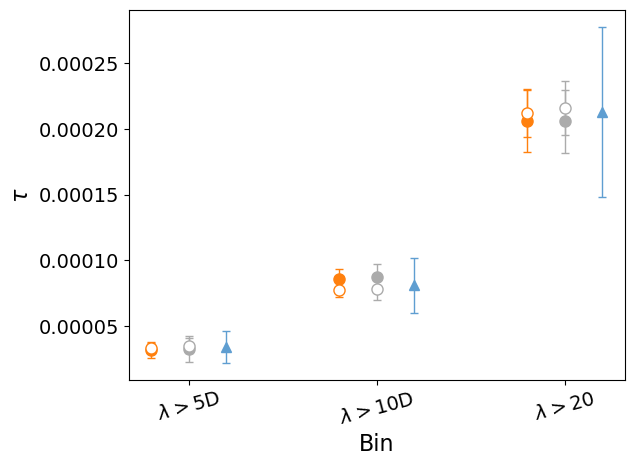

In [16]:
mfcs = [None, 'white']
names = ['CIB-deproj. tSZ ', r'd$\beta$-deproj. tSZ ', 'ILC kSZ ']
skips = [0, 0.2, 0.3]
for j, m in enumerate(['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']):
    for i, lum in enumerate(lums):
        for k, ind in enumerate(inds):
            combined_err = tau_df.loc[lum+ind, m+'_tsz_tau_staterr']+tau_df.loc[lum+ind, m+'_tsz_tau_syserr']
            plt.errorbar(i+skips[j], tau_df.loc[lum+ind, m+'_tsz_tau'], yerr=combined_err, color=colors[1+j], mfc=mfcs[k], label=names[j]+ind, **errbar_kwargs)
for i, lum in enumerate(lums):
    plt.errorbar(i+0.4, tau_df.loc[lum+ind, 'ilc_ksz_tau'], tau_df.loc[lum+ind, 'ilc_ksz_tau_err'], color=colors[4], label=names[2], **errbar_kwargs_tri)
plt.xticks(np.arange(len(lums))+0.2, [r'$\lambda >$' +f'{lum[1:]}' for lum in lums], rotation=15)
plt.xlabel('Bin')
plt.ylabel(r'$\tau$')